In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import itertools
%matplotlib widget

In [2]:

    α = .7
    η1 = .9
    η2 = .9
    nbar = 0.01
    r = .1
    a = .7

    Ω = np.array([
        [0,1,0,0,0,0],
        [-1,0,0,0,0,0],
        [0,0,0,1,0,0],
        [0,0,-1,0,0,0],
        [0,0,0,0,0,1],
        [0,0,0,0,-1,0]
    ])

In [3]:
def σ(η1,η2,α,r):
    l1 = [1+2*η1*α**2*np.sinh(r)**2 + 2*nbar, 0, -2*α*np.sqrt((1-α**2)*η1*η2)*np.sinh(r)**2,0, -2*α*np.sqrt(η1)*np.sinh(r)*np.cosh(r),0]
    l2 = [0,1+2*η1*α**2*np.sinh(r)**2 + 2*nbar, 0, -2*α*np.sqrt((1-α**2)*η1*η2)*np.sinh(r)**2,0, 2*α*np.sqrt(η1)*np.sinh(r)*np.cosh(r)]
    l3 = [-2*α*np.sqrt((1-α**2)*η1*η2)*np.sinh(r)**2,0,1+2*η2*(1-α**2)*np.sinh(r)**2+2*nbar,0,2*np.sqrt(η2*(1-α**2))*np.sinh(r)*np.cosh(r),0]
    l4 = [0,-2*α*np.sqrt((1-α**2)*η1*η2)*np.sinh(r)**2,0,1+2*η2*(1-α**2)*np.sinh(r)**2+2*nbar,0,-2*np.sqrt(η2*(1-α**2))*np.sinh(r)*np.cosh(r)]
    l5 = [-2*α*np.sqrt(η1)*np.sinh(r)*np.cosh(r),0,2*np.sqrt(η2*(1-α**2))*np.sinh(r)*np.cosh(r),0,1+2*np.sinh(r)**2,0]
    l6 = [0,2*α*np.sqrt(η1)*np.sinh(r)*np.cosh(r),0,-2*np.sqrt(η2*(1-α**2))*np.sinh(r)*np.cosh(r),0,1+2*np.sinh(r)**2]
    σ = np.array([l1,l2,l3,l4,l5,l6])
    return σ

In [4]:
def dσdη1(η1,η2,α,r):
    l1 = [2*α**2*np.sinh(r)**2,0, -α*np.sqrt((1-α**2)*η2/η1)*np.sinh(r)**2,0,-α*np.sqrt(1/η1)*np.sinh(r)*np.cosh(r),0]
    l2 = [0,2*α**2*np.sinh(r)**2,0, -α*np.sqrt((1-α**2)*η2/η1)*np.sinh(r)**2,0,α*np.sqrt(1/η1)*np.sinh(r)*np.cosh(r)]
    l3 = [-α*np.sqrt((1-α**2)*η2/η1)*np.sinh(r)**2,0,0,0,0,0]
    l4 = [0,-α*np.sqrt((1-α**2)*η2/η1)*np.sinh(r)**2,0,0,0,0]
    l5 = [-α*np.sqrt(1/η1)*np.sinh(r)*np.cosh(r),0,0,0,0,0]
    l6 = [0,α*np.sqrt(1/η1)*np.sinh(r)*np.cosh(r),0,0,0,0]
    dσdη1 = np.array([l1,l2,l3,l4,l5,l6])
    return dσdη1

In [5]:
def dσdη2(η1,η2,α,r):
    l1 = [0,0,-α*np.sqrt((1-α**2)*η1/η2)*np.sinh(r)**2,0,0,0]
    l2 = [0,0,0,-α*np.sqrt((1-α**2)*η1/η2)*np.sinh(r)**2,0,0]
    l3 = [-α*np.sqrt((1-α**2)*η1/η2)*np.sinh(r)**2,0,2*(1-α**2)*np.sinh(r)**2,0,np.sqrt((1-α**2)/η2)*np.sinh(r)*np.cosh(r),0]
    l4 = [0,-α*np.sqrt((1-α**2)*η1/η2)*np.sinh(r)**2,0,2*(1-α**2)*np.sinh(r)**2,0,-np.sqrt((1-α**2)/η2)*np.sinh(r)*np.cosh(r)]
    l5 = [0,0,np.sqrt((1-α**2)/η2)*np.sinh(r)*np.cosh(r),0,0,0]
    l6 = [0,0,0,-np.sqrt((1-α**2)/η2)*np.sinh(r)*np.cosh(r),0,0]
    dσdη2 = np.array([l1,l2,l3,l4,l5,l6])
    return dσdη2

In [6]:
# Williamson Decomp
def will_decomp(σ):
    # Currently built for 6x6 covariance matricies, but could be adapted for other matricies
    sqrt = sp.linalg.sqrtm(σ)
    invsqrt = sp.linalg.fractional_matrix_power(sqrt,-.5)
    Ψ = invsqrt@Ω@invsqrt
    #[T,Z,_] = sp.linalg.schur(Ψ,output='real',sort='lhp')
    [T,Z] = sp.linalg.schur(Ψ,output='real')
    I2 = np.array([[1,0],[0,1]])
    Px = np.array([[0,1],[1,0]])
    Πl = [I2 if T[2*i,2*i+1] >0 else Px for i in range(3)]
    Π = sp.linalg.block_diag(Πl[0],Πl[1],Πl[2])
    Dinv = np.abs(np.linalg.diagonal(T@Ω))
    Dinvsqrt = np.sqrt(Dinv)
    Dt =  np.reciprocal(Dinv)
    St = sqrt@Z@Π@np.diag(Dinvsqrt)
    err = -St@Ω@np.transpose(St)@Ω
    fix = sp.linalg.fractional_matrix_power(err,-.5)
    S = fix@St
    Sinv = -Ω@np.transpose(S)@Ω
    SinvT = np.transpose(Sinv)
    ν = [(Sinv@σ@SinvT)[2*i][2*i] for i in range(3)]
    # D = np.linalg.diagonal(err@np.diag(Dt))
    #print(St@np.diag(Dt)@np.transpose(St)-σ)
    #print(np.round(St@Ω@np.transpose(St),5))
    #print(Dt)
    #print(np.round(S@Ω@np.transpose(S),8))
    return [S,ν]

In [7]:
#[S,ν] = will_decomp(σ)

In [8]:
def _SLD_precomp(σ):
    [S,ν] = will_decomp(σ)
    Sinv = -Ω@np.transpose(S)@Ω
    SinvT = np.transpose(Sinv)
    def M(j,k,l):
        Mval = np.zeros([6,6])
        outputs = {
            0: [[0,1],[-1,0]],
            1: [[0,1],[1,0]],
            2: [[1,0],[0,1]],
            3: [[1,0],[0,-1]]
        }
        Mval[(2*j):(2*j+2),(2*k):(2*k+2)] = outputs[l]
        return Mval
    newM = [[[SinvT@M(j,k,l)@Sinv for l in range(3)] for k in range(3)] for j in range(3)]
    return [newM,ν]

In [9]:
def SLD(σ,dσ,precomp = None):
    if precomp is None:
        precomp = _SLD_precomp(σ)
    newM = precomp[0]
    ν=precomp[1]
    Lsum = [[[ newM[i][j][l] * 1/(ν[i]*ν[j] - (-1)**l)*np.linalg.trace(newM[i][j][l]@dσ) for i in range(3)] for j in range(3)] for l in range(3)]
    L = np.sum(Lsum,axis=(0,1,2))
    return L
    #print(ν)
    #print(np.round(Sinv@σ@SinvT,8))

In [10]:
    #Lsumη1 = [[[ newM[i][j][l] * 1/(ν[i]*ν[j] - (-1)**l)*np.linalg.trace(newM[i][j][l]@dσdη1) for i in range(3)] for j in range(3)] for l in range(3)]
    #Lη1 = np.sum(Lsumη1,axis=(0,1,2))/2
    #Lη1 = SLD(σ,dσdη1)
    #Lη2 = SLD(σ,dσdη2)
    #Lsumη2 = [[[ newM[i][j][l] * 1/(ν[i]*ν[j] - (-1)**l)*np.linalg.trace(newM[i][j][l]@dσdη2) for i in range(3)] for j in range(3)] for l in range(3)]
    #Lη2 = np.sum(Lsumη2,axis=(0,1,2))/2

In [11]:
def FIM(σ,dσs):
    precomp = _SLD_precomp(σ)
    Ls = [SLD(σ,dσ,precomp) for dσ in dσs]
    FIM = np.array([[ np.linalg.trace(L@dσ)/2 for L in Ls] for dσ in dσs])
    return FIM
    #FIη11 = np.linalg.trace(Lη1@dσdη1)/2
    #FIη22 = np.linalg.trace(Lη2@dσdη2)/2
    #FIη12 = np.linalg.trace(Lη1@dσdη2)/2
    #FIη21 = np.linalg.trace(Lη2@dσdη1)/2
    #FIM = np.array([[FIη11,FIη12],[FIη21,FIη22]])
    #print(FIM)


In [12]:
    #FIη11 = np.linalg.trace(Lη1@dσdη1)/2
    #FIη22 = np.linalg.trace(Lη2@dσdη2)/2
    #FIη12 = np.linalg.trace(Lη1@dσdη2)/2
    #FIη21 = np.linalg.trace(Lη2@dσdη1)/2
    #FIM = np.array([[FIη11,FIη12],[FIη21,FIη22]])

In [13]:
def FIE(FIM,a):
    # Currently only written for 2 parameter estimation
    aeff = a if (np.abs(a) > .5) else (-a+ np.sign(a))
    Bm1 = [[aeff,0],[np.sqrt(1-aeff**2),1]]
    Qtm1 = np.transpose(Bm1)@np.linalg.inv(FIM)@Bm1
    FIE = 1/Qtm1[0,0]
    return FIE
    #print(FIE)
    #print(np.linalg.inv(FIM))

In [14]:
#FIMval = FIM(σ,[dσdη1,dσdη2])

In [15]:
#FIMval

In [16]:
#FIE(FIMval,a)

In [17]:
def vec_eval(η1s,η2s,αs,rs,avals):
    nη1 = len(η1s)
    nη2 = len(η2s)
    nα = len(αs)
    nr = len(rs)
    na = len(avals)
    [η1grid,η2grid,αgrid,rgrid] = np.meshgrid(η1s,η2s,αs,rs)
    QFIEs = np.zeros((nη1,nη2,nα,nr,na))
    ivals = itertools.product(range(nη1),range(nη2),range(nα),range(nr))
    for (i1,i2,i3,i4) in tqdm(ivals,total = nη1*nη2*nα*nr,smoothing=.01):
        η1 = η1grid[i1,i2,i3,i4]
        η2 = η2grid[i1,i2,i3,i4]
        α = αgrid[i1,i2,i3,i4]
        r = rgrid[i1,i2,i3,i4]
        σval = σ(η1,η2,α,r)
        dσs = [dσdη1(η1,η2,α,r),dσdη2(η1,η2,α,r)]
        FIMval = FIM(σval,dσs)
        for i5 in range(na):
            QFIEs[i1,i2,i3,i4,i5] = FIE(FIMval,avals[i5])
    return QFIEs

In [18]:
def eval_settings(η1,η2,α,r,a):
    σval = σ(η1,η2,α,r)
    dσs = [dσdη1(η1,η2,α,r),dσdη2(η1,η2,α,r)]
    FIMval = FIM(σval,dσs)
    return FIE(FIMval,a)

In [19]:
#fig = plt.figure()
#ax = fig.add_subplot(projection='3d')
#[agrid,αgrid] = np.meshgrid(avals,αvals)
#ax.plot_surface(ηgrid,agrid,np.transpose(QFIgrid))
#ax.plot_surface(agrid,αgrid,np.transpose(np.array(QFIEs)))
#plt.show()

In [20]:
def save_state(filename):
    np.savez_compressed(filename, eta1s = η1s, eta2s = η2s,alphavals = αvals,rvals=rvals,avals=avals,QFIEs=QFIEs)

In [21]:
η1s = np.linspace(.01,.99,100)
η2s = η1s
αvals = np.linspace(-.991,.99,1000)
rvals = [.001]
avals = np.linspace(-.99,.99,100)
#QFIEs = vec_eval(η1s,η2s,αvals,rvals,avals)
#np.save('QFIEs2',QFIEs)
#save_state('QFIEs2')
#QFIEs = np.load('QFIEs2.npy')

In [22]:
def load_state(filename):
    loaded = np.load(filename)
    return [loaded['eta1s'],loaded['eta2s'],loaded['alphavals'],loaded['rvals'],loaded['avals'],loaded['QFIEs']]

In [23]:
[η1s, η2s, αvals, rvals, avals, QFIEs] = load_state('QFIEs2.npz')


In [24]:
np.shape(QFIEs)

(100, 100, 1000, 1, 100)

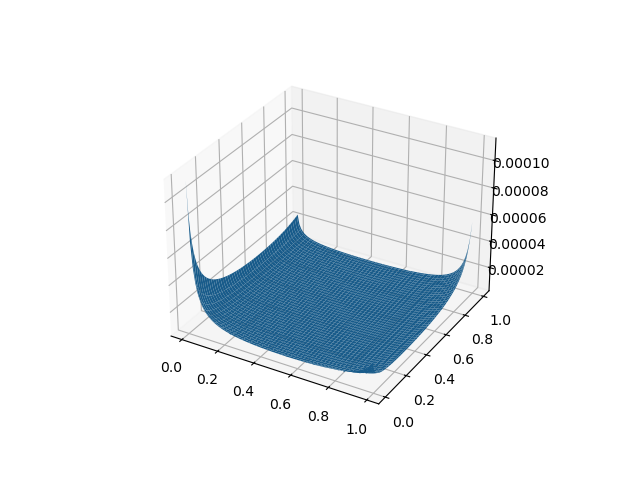

In [25]:
target = np.sqrt(1/100)
targetarg = np.argmin(np.abs(avals-target))
targeteddata = QFIEs[:,:,:,0,targetarg]
maximized = np.nanmax(targeteddata,axis=2)
[η1grid,η2grid] = np.meshgrid(η1s,η2s)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,maximized)
plt.show()

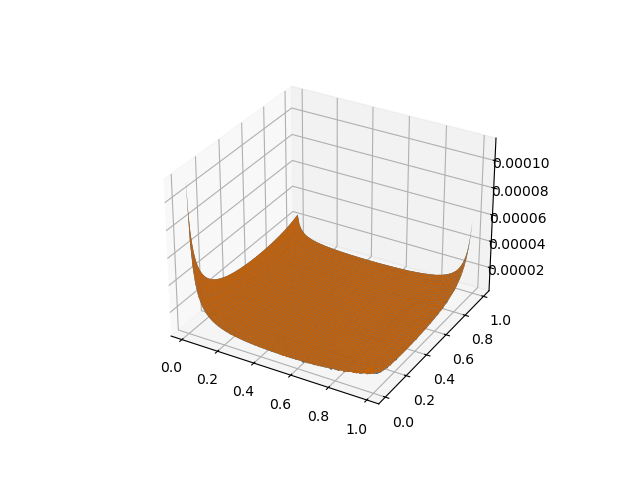

In [26]:
zeroval = np.argmin(np.abs(αvals))
maximizedpos = np.nanmax(QFIEs[:,:,zeroval:,0,targetarg],axis=2)
maximizedneg = np.nanmax(QFIEs[:,:,0:zeroval,0,targetarg],axis=2)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,maximizedpos)
ax.plot_surface(η1grid,η2grid,maximizedneg)
plt.show()

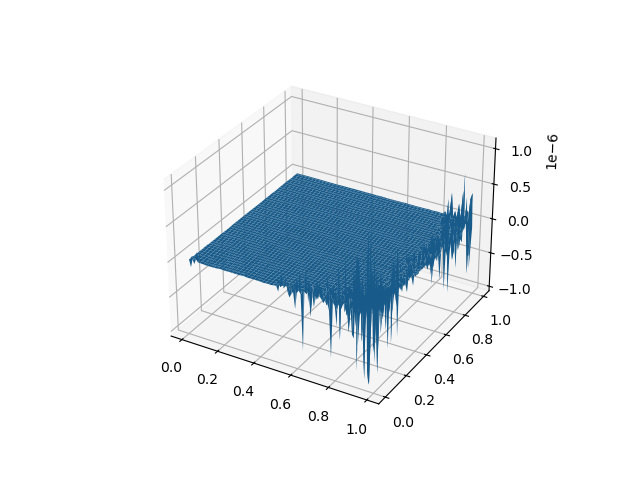

In [27]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,sp.signal.wiener(maximizedpos-maximizedneg,(10,10)))
plt.show()

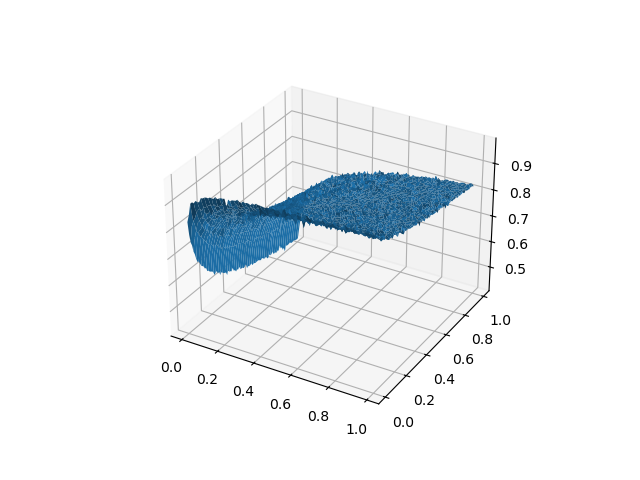

In [28]:
αmax = αvals[np.nanargmax(targeteddata,axis=2)]
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,np.abs(αmax))
plt.show()

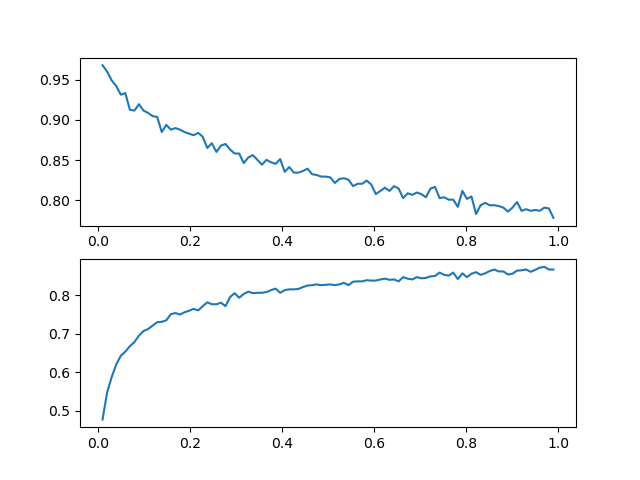

In [29]:

split1 = np.argmin(np.abs(.5-η1s))
split2 = np.argmin(np.abs(.5-η2s))

oneddata1 = αmax[split1,:]
oneddata2 = αmax[:,split2]
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
ax1.plot(η1s,np.abs(oneddata2))
ax2.plot(η2s,np.abs(oneddata1))
plt.show()

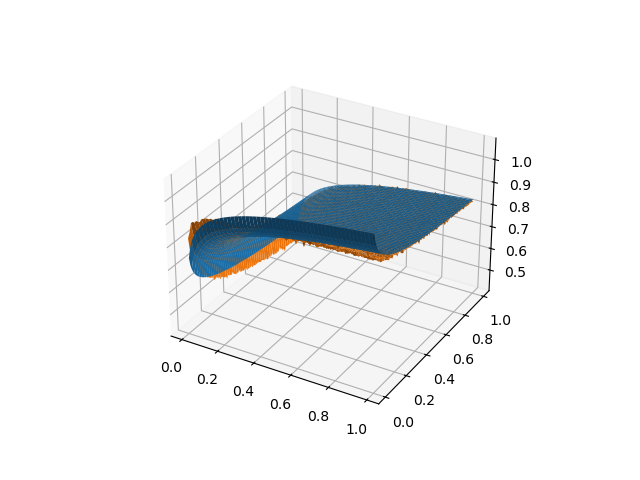

In [30]:
xdata = np.vstack((η1grid.ravel(), η2grid.ravel()))
ydata = np.abs(αmax).ravel()
p0 = [0,1,-1]
def _logvals(X,x0,l1,l2):
    return x0+l1*np.log(X[0]) + l2*np.log(X[1])
def _jac_logvals(X,x0,l1,l2):
    return np.transpose(np.array([np.ones(X[0].shape),np.log(X[0]),np.log(X[1])]))
popt, pcov = sp.optimize.curve_fit(_logvals, xdata, ydata, p0,jac=_jac_logvals)
fitteddata = popt[0] + popt[1]*np.log(η1grid) + popt[2]*np.log(η2grid)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,fitteddata)
ax.plot_surface(η1grid,η2grid,np.abs(αmax))

plt.show()

In [95]:
def fitα(fitfunc,data,aval,η1s,η2s,avals,p0,bounds=(-np.inf,np.inf)):
    targetarg = np.argmin(np.abs(avals-aval))
    αmax = np.abs(αvals[np.nanargmax(data[:,:,:,0,targetarg],axis=2)])
    η1grid, η2grid = np.meshgrid(η1s,η2s)
    xdata = np.vstack((η1grid.ravel(), η2grid.ravel()))
    ydata = αmax.ravel()
    popt, pcov = sp.optimize.curve_fit(fitfunc, xdata, ydata, p0,bounds=bounds)#,jac=_jac_logvals)
    fitteddata = fitfunc(np.array([η1grid,η2grid]),*popt)
    res = αmax-fitteddata
    totalerr = np.sqrt(np.sum(res**2))
    return [*popt,totalerr]


  0%|          | 0/100 [00:00<?, ?it/s]

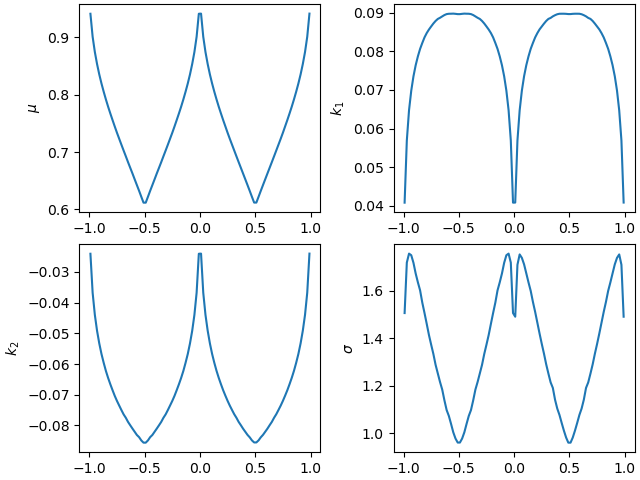

In [96]:
def _logvals(X,*args):
    (x0,l1,l2) = args
    return x0+l1*np.log(X[0]) + l2*np.log(X[1])
p0 = [0,1,-1]
fits = np.array([fitα(_logvals,QFIEs,aval,η1s,η2s,avals,p0) for aval in tqdm(avals)])
fig, axes = plt.subplots(2,2,layout='constrained')
ylabels = [r'$\mu$',r'$k_1$',r'$k_2$',r'$\sigma$']
for i in range(2):
    for j in range(2):
        axes[i,j].plot(avals,fits[:,2*i+j])
        axes[i,j].set_ylabel(ylabels[2*i+j])
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

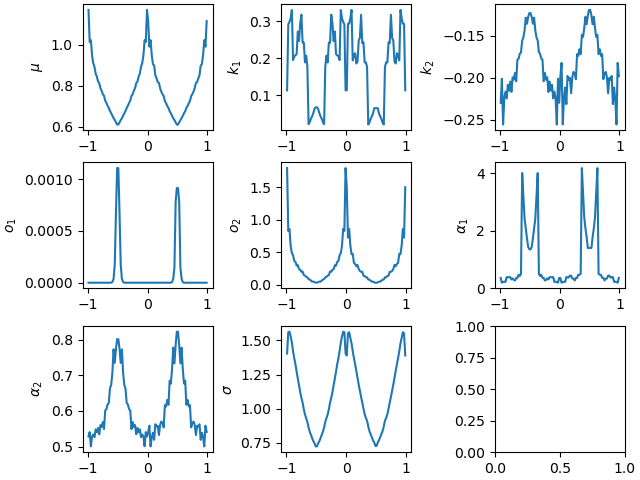

In [102]:
def _logp1vals(X,*args):
    (x0,l1,l2,o1,o2,α1,α2) = args
    return x0+l1*np.log(X[0]**α1+o1) + l2*np.log(X[1]**α2+o2)
p0 = [0,1,-1,0,0,1/2,1/2]
bounds = ([-1,-np.inf,-np.inf,0,0,0,0],[np.inf,np.inf,np.inf,10,10,10,10])
fits = np.array([fitα(_logp1vals,QFIEs,aval,η1s,η2s,avals,p0,bounds=bounds) for aval in tqdm(avals)])
fig, axes = plt.subplots(3,3,layout='constrained')
ylabels = [r'$\mu$',r'$k_1$',r'$k_2$',r'$o_1$',r'$o_2$',r'$\alpha_1$',r'$\alpha_2$',r'$\sigma$']
for i in range(3):
    for j in range(3):
        if i==2 and j==2:
            continue
        axes[i,j].plot(avals,fits[:,3*i+j])
        axes[i,j].set_ylabel(ylabels[3*i+j])
plt.show()

In [33]:
print(popt)

[ 0.8354997   0.07353884 -0.05327728]


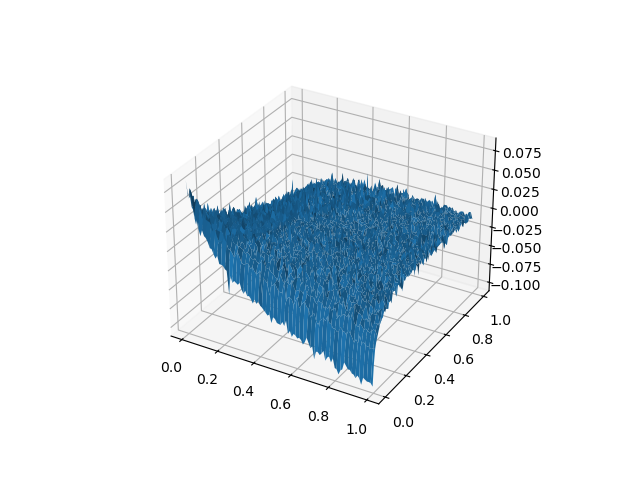

In [34]:
res = np.abs(αmax)-fitteddata
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,res)
plt.show()

In [35]:
totalerr = np.sum(res**2)
print(totalerr)

2.9285119806353705


In [36]:
xdata = np.vstack((η1grid.ravel(), η2grid.ravel()))
ydata = np.abs(αmax).ravel()
p0 = [0,1,-1]
def _arcsinhvals(X,x0,l1,l2):
    return x0+l1*np.arcsinh(X[0]) + l2*np.arcsinh(X[1])
def _jac_arcsinhvals(X,x0,l1,l2):
    return np.transpose(np.array([np.ones(X[0].shape),np.arcsinh(X[0]),np.arcsinh(X[1])]))
popt, pcov = sp.optimize.curve_fit(_arcsinvals, xdata, ydata, p0,jac=_jac_arctanhvals)
fitteddata = popt[0] + popt[1]*np.arctanh(1-η1grid) + popt[2]*np.arctanh(1-η2grid)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,fitteddata)
ax.plot_surface(η1grid,η2grid,np.abs(αmax))

plt.show()

NameError: name '_arcsinvals' is not defined

In [ ]:
res = np.abs(αmax)-fitteddata
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,res)
plt.show()

In [ ]:
totalerr = np.sum(res**2)
print(totalerr)

In [ ]:
selector = αmax >0
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(η1grid[selector],η2grid[selector],αmax[selector])
ax.plot_trisurf(η1grid[selector!=True],η2grid[selector!=True],-αmax[selector!=True])
plt.show()

In [ ]:
# Code to maybe lowpass the data
def butter_lowpass(cutoff, fs, order=5):
    return sp.signal.butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y1 = sp.signal.lfilter(b, a, data,axis=0)
    y2 = sp.signal.lfilter(b, a, y1,axis=1)
    return y2


In [ ]:
maximizedargpos = αvals[np.nanargmax(QFIEs[:,:,zeroval:,0,targetarg],axis=2)+zeroval]
maximizedargneg = αvals[np.nanargmax(QFIEs[:,:,0:zeroval,0,targetarg],axis=2)]
diffval = maximizedargpos+maximizedargneg
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,diffval)
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(η1grid,η2grid,butter_lowpass_filter(diffval,.2,30))
plt.show()